# **Load in 30 digit images (0, 1, 2) for testing VAE architecture & loss functions**

In [ ]:
# mount gdrive with this code
from google.colab import drive
drive.mount('/content/drive')
#below where the file is in gdrive, change with your
image_dir = "/content/drive/My Drive/Vision_AI_Dataset/Data_DigitImg_012_Each10/"

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

In [ ]:
image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir)
               if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

# Load all images and convert to numpy arrays
images = []
classes = []
out_images = []
for img_path in image_files:
    # Extract the filename from the path
    filename = os.path.basename(img_path)
    # Split the filename by '_' and find the part that is a digit
    parts = filename.split("_")
    num = None
    for part in parts:
        if part.isdigit():
            num = int(part)
            break
    if num is not None:
        classes.append(num)
        img = load_img(img_path, color_mode='grayscale')  # change size as needed
        img = img_to_array(img) / 255.0  # normalize to [0,1]
        images.append(img)
    else:
        print(f"Could not extract digit from filename: {filename}")

# Convert list to numpy array
x_all = np.array(images)

In [ ]:
print(classes)

[1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 1]


In [ ]:
print(type(x_all), {x_all.dtype})
print("Loaded images:", x_all.shape)
max_val = x_all.max()
min_val = x_all.min()
print("Max & Min Vals:", max_val, min_val)

<class 'numpy.ndarray'> {dtype('float32')}
Loaded images: (30, 28, 28, 1)
Max & Min Vals: 1.0 0.0


In [ ]:
# --- Data Loading and Preprocessing ---
x_train = x_all
x_test = x_all

input_shape = (28, 28, 1)
x_train = x_all
x_test = x_all

"""
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
"""

print("Loaded images:", x_train.shape)
print("Loaded images:", x_test.shape)

Loaded images: (30, 28, 28, 1)
Loaded images: (30, 28, 28, 1)


# **VAE Architecture**

**Unique & strange "sampling_layer" function**

In [ ]:
"""
The sampling_layer function is necessary because of a problem with
standard backpropagation in VAEs: You cannot backpropagate
through a random sampling process.
"""
# --- Functional Layer for Reparameterization Trick ---
def sampling_layer(inputs):
    # Implements the reparameterization trick: z = mu + sigma * epsilon.
    z_mean, z_log_var = inputs
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]

    # Sample epsilon from a standard normal distribution
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))

    # Calculate standard deviation: exp(0.5 * z_log_var)
    sigma = tf.exp(0.5 * z_log_var)

    # Final latent vector z
    return z_mean + sigma * epsilon

In [ ]:
# --- Encoder Network (Functional Model) ---
def create_encoder(input_shape, latent_dim):
    """
    Creates the CNN VAE Encoder model.
    """
    encoder_inputs = keras.Input(shape=input_shape, name="encoder_input")
    x = encoder_inputs

    # Convolutional layers
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)

    # Store the shape before flattening for the *****decoder*****
    conv_shape = tf.keras.backend.int_shape(x)

    # Flatten to connect to the latent layer
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation="relu")(x)

    # Output layer for the parameters of the latent distribution
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

    """
    [z_mean, z_log_var] = major output from encoder
    conv_shape = output the shape for building the first layer in the decoder
    """
    return keras.Model(encoder_inputs, [z_mean, z_log_var], name="encoder"), conv_shape

In [ ]:
# --- Decoder Network (Functional Model) ---
def create_decoder(latent_dim, output_shape, conv_shape):
    """
    Creates the CNN VAE Decoder model using Conv2DTranspose.
    """
    latent_inputs = keras.Input(shape=(latent_dim,), name="z_sampling")
    x = latent_inputs

    # Start with a Dense layer to expand latent vector
    x = layers.Dense(conv_shape[1] * conv_shape[2] * conv_shape[3], activation="relu")(x)

    # Reshape back to the convolutional feature map dimensions
    x = layers.Reshape((conv_shape[1], conv_shape[2], conv_shape[3]))(x)

    # Deconvolutional layers (Conv2DTranspose) for upsampling
    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)

    # Final layer to reconstruct the image (1 channel, sigmoid activation)
    decoder_outputs = layers.Conv2DTranspose(
        output_shape[-1], 3, activation="sigmoid", padding="same", name="decoder_output"
    )(x)

    return keras.Model(latent_inputs, decoder_outputs, name="decoder")

# **Full VAE with layers.Lambda**
Use this to wrap an arbitrary function as a layer to allow you to insert custom, simple, non-trainable operations into the model's graph (i.e. network) structure.

The first argument is a function called **"sampling_layer" (reparameterization)**

Purpose: It lets you perform operations that don't have a standard, pre-built Keras layer (in our case "sampling_layer").

In [ ]:
# --- Full VAE Model (Functional API) ---
def connect_vae_model(encoder_model, decoder_model, input_shape, latent_dim):
    """
    Combines the Encoder and Decoder using the Functional API.
    The model returns the reconstruction, z_mean, and z_log_var for manual loss calculation.
    """
    vae_inputs = keras.Input(shape=input_shape, name="vae_input")

    # Forward pass through the encoder
    z_mean, z_log_var = encoder_model(vae_inputs)

    # Reparameterization step*********************
    z = layers.Lambda(sampling_layer, output_shape=(latent_dim,), name='z_sampled')([z_mean, z_log_var])

    # Forward pass through the decoder
    reconstruction = decoder_model(z)

    # Model returns all components needed for the custom loss function
    vae = keras.Model(vae_inputs, [reconstruction, z_mean, z_log_var], name="vae_cnn_functional")

    # *******************************************************************
    # CRITICAL: Define the Z-EXTRACTION MODEL
    # This model takes X as input and outputs the sampled Z vector.
    # *******************************************************************
    z_extractor = keras.Model(vae_inputs, z, name="z_extractor")

    return vae, z_extractor # Return both models

In [ ]:
# --- Custom Loss Functions ---
def reconstruction_loss_fn(x, reconstruction):
    """
    Calculates the Binary Cross-Entropy (BCE) loss.
    Loss must be summed over the entire image (axes 1, 2, 3) and then averaged over the batch.
    """
    # keras.losses.binary_crossentropy returns loss per pixel/channel
    bce = keras.losses.binary_crossentropy(x, reconstruction)

    # Sum over height and width dimensions (axis 1 and 2)
    reconstruction_loss = tf.reduce_sum(bce, axis=[1, 2])

    # Average over the batch
    return tf.reduce_mean(reconstruction_loss)

def kl_loss_fn(z_mean, z_log_var):
    """
    Calculates the KL Divergence loss (regularization term).
    Formula: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    """
    kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))

    # Sum over the latent dimension (axis 1) and average over the batch
    return tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

# **Prepare training for EACH batch**

In [ ]:
# --- Training Step for Training Each batch ---

@tf.function
def train_step_fn(x_batch, vae, optimizer):
    """
    The main training step function executed once per batch.
    Uses @tf.function for optimal performance.
    """
    with tf.GradientTape() as tape:
        # 1. Forward Pass: Get all outputs needed for loss calculation
        # The VAE model returns: [reconstruction, z_mean, z_log_var]
        reconstruction, z_mean, z_log_var = vae(x_batch)

        # 2. Calculate component losses
        reconstruction_loss = reconstruction_loss_fn(x_batch, reconstruction)
        kl_loss = kl_loss_fn(z_mean, z_log_var)

        # 3. Combined Loss
        beta = 1.0  # Weighting factor for KL loss
        total_loss = reconstruction_loss + (beta * kl_loss)

    # 4. Backpropagation: Compute and Apply Gradients
    # tape.gradient calculates derivatives of the total_loss w.r.t all trainable weights
    grads = tape.gradient(total_loss, vae.trainable_weights)
    # optimizer.apply_gradients updates the weights
    optimizer.apply_gradients(zip(grads, vae.trainable_weights))

    # Return losses for logging
    return total_loss, reconstruction_loss, kl_loss

**Create Encoder, Decoder and a complete VAE**

In [ ]:
# --- Model Setup ---
latent_dim = 32

# Encoder and capture the necessary shape for the decoder
encoder_model, conv_shape = create_encoder(input_shape, latent_dim)

# Decoder
decoder_model = create_decoder(latent_dim, input_shape, conv_shape)

# Final VAE, z_extractor_model models (returns all necessary tensors)
vae, z_extractor_model = connect_vae_model(encoder_model, decoder_model, input_shape, latent_dim)

**Configure optmizer, learning rate, and metrics**

In [ ]:
# Optimizer and Metrics setup
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

# Keras Metrics for smooth logging
total_loss_metric = keras.metrics.Mean()
reconstruction_loss_metric = keras.metrics.Mean()
kl_loss_metric = keras.metrics.Mean()

**create tf.data.Dataset for shuffling & batches**

In [ ]:
BATCH_SIZE = 128
EPOCHS = 300

# Create tf.data.Dataset for efficient iteration in the custom loop
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(BATCH_SIZE)

### **Training through epoches and batches.**
**Function in processing each bat is in "train_step_fn()"**

In [ ]:
# --- Training Loop ---
print("--- Starting CNN-VAE Training with Manual Loop ---")

for epoch in range(1, EPOCHS + 1):
    # Reset metrics at the start of each epoch
    total_loss_metric.reset_state()
    reconstruction_loss_metric.reset_state()
    kl_loss_metric.reset_state()

    # Iterating through batches
    for step, x_batch in enumerate(train_dataset):
        # Execute the training step function
        t_loss, r_loss, k_loss = train_step_fn(x_batch, vae, optimizer)

        # Update metrics
        total_loss_metric.update_state(t_loss)
        reconstruction_loss_metric.update_state(r_loss)
        kl_loss_metric.update_state(k_loss)

        if step % 100 == 0:
            print(
                f"Epoch {epoch} | Step {step}/{len(train_dataset)} | "
                f"Total Loss: {total_loss_metric.result().numpy():.4f} | "
                f"Recon Loss: {reconstruction_loss_metric.result().numpy():.4f} | "
                f"KL Loss: {kl_loss_metric.result().numpy():.4f}"
            )

    print(
        f"\n--- EPOCH {epoch} SUMMARY --- | "
        f"Avg Total Loss: {total_loss_metric.result().numpy():.4f} | "
        f"Avg Recon Loss: {reconstruction_loss_metric.result().numpy():.4f} | "
        f"Avg KL Loss: {kl_loss_metric.result().numpy():.4f}\n"
    )

print("--- Training Complete ---")

--- Starting CNN-VAE Training with Manual Loop ---
Epoch 1 | Step 0/1 | Total Loss: 545.2320 | Recon Loss: 545.2269 | KL Loss: 0.0052

--- EPOCH 1 SUMMARY --- | Avg Total Loss: 545.2320 | Avg Recon Loss: 545.2269 | Avg KL Loss: 0.0052

Epoch 2 | Step 0/1 | Total Loss: 538.3294 | Recon Loss: 538.3257 | KL Loss: 0.0037

--- EPOCH 2 SUMMARY --- | Avg Total Loss: 538.3294 | Avg Recon Loss: 538.3257 | Avg KL Loss: 0.0037

Epoch 3 | Step 0/1 | Total Loss: 531.4191 | Recon Loss: 531.4175 | KL Loss: 0.0015

--- EPOCH 3 SUMMARY --- | Avg Total Loss: 531.4191 | Avg Recon Loss: 531.4175 | Avg KL Loss: 0.0015

Epoch 4 | Step 0/1 | Total Loss: 524.4291 | Recon Loss: 524.4277 | KL Loss: 0.0014

--- EPOCH 4 SUMMARY --- | Avg Total Loss: 524.4291 | Avg Recon Loss: 524.4277 | Avg KL Loss: 0.0014

Epoch 5 | Step 0/1 | Total Loss: 516.2684 | Recon Loss: 516.2646 | KL Loss: 0.0038

--- EPOCH 5 SUMMARY --- | Avg Total Loss: 516.2684 | Avg Recon Loss: 516.2646 | Avg KL Loss: 0.0038

Epoch 6 | Step 0/1 | Tot

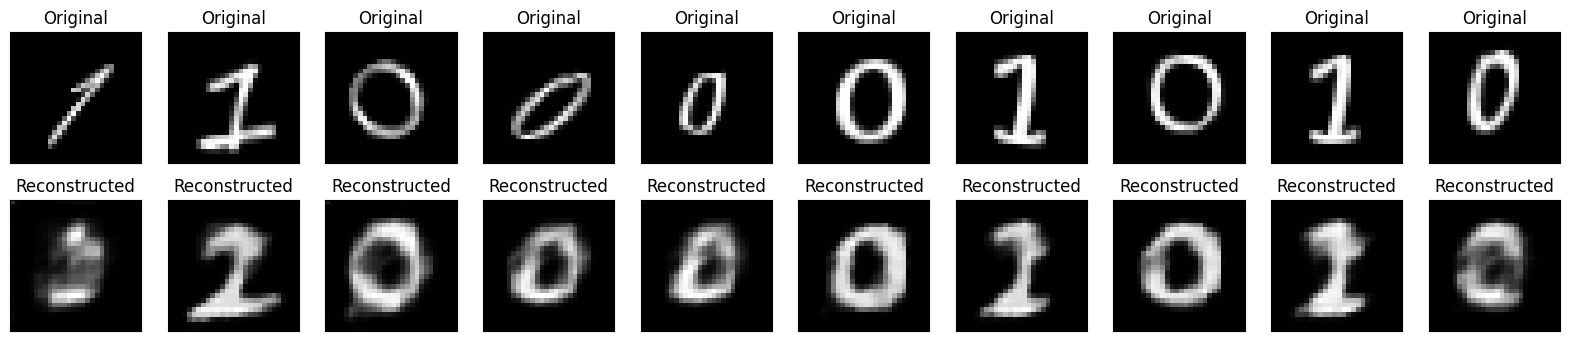

In [ ]:
# --- Visualization and Main Execution ---
def plot_reconstructions(vae, data, n=10):
    """Plots original and reconstructed digits."""

    # The VAE model must be re-called / re-build to get the outputs
    reconstructions, _, _ = vae(data)    # data = randomly selected test images

    # Setup figure
    plt.figure(figsize=(20, 4))

    for i in range(n):
        # Original Image
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i].numpy().squeeze(), cmap='gray')
        plt.title("Original")
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Reconstructed Image
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructions[i].numpy().squeeze(), cmap='gray')
        plt.title("Reconstructed")
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

################################
# --- Results Visualization ---
# Convert test images to tensor for visualization call
x_test_tensor = tf.convert_to_tensor(x_test[:10])
plot_reconstructions(vae, x_test_tensor)

## **Above: not bad reconstructions from training data.**

# **Next, try to see if Zs from encoder are "well structured"...**

In [ ]:
# Use the encoder to get the latent representation
# The .predict() method on the encoder returns a list of outputs
# In this case, [z_mean, z_log_var, z_sampled_vectors]
z_sampled_vectors = z_extractor_model.predict(x_train)

print("\n--- Z Latent Vector Extraction ---")
print(f"Input X shape: {x_train.shape}")
print(f"Sampled Z shape: {z_sampled_vectors.shape}")
print("\nFirst 5 sampled Z vectors (z):")
print(z_sampled_vectors[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

--- Z Latent Vector Extraction ---
Input X shape: (30, 28, 28, 1)
Sampled Z shape: (30, 32)

First 5 sampled Z vectors (z):
[-0.4697299   1.3586767  -2.899621   -2.425273   -0.56135887  0.1892762
 -0.12296328 -1.4336647  -1.1960626   0.664538    1.5594084  -2.920162
  1.2735455   1.8893324   0.137355   -1.116837   -2.6601048   0.07982659
  0.36365956 -1.5936021  -0.9530791  -0.9016297   1.3548697  -1.3057363
 -0.08907887 -0.42082494  0.22475003 -0.86291695 -0.47379786  0.04647391
  0.46832997 -1.0377479 ]


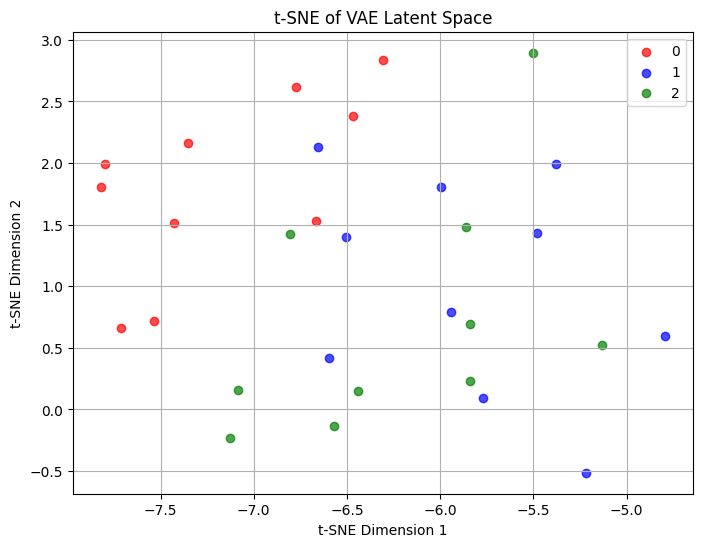

In [ ]:
from sklearn.manifold import TSNE

z = z_sampled_vectors

# Assuming z is (num_samples, latent_dim)
# and labels is (num_samples,)

# Run t-SNE to reduce z to 2 dimensions
tsne = TSNE(n_components=2, random_state=42, perplexity=20) # Reduced perplexity
labels = classes # Added the missing labels variable
z_2d = tsne.fit_transform(z)

# Define class names and colors
class_names = ["0", "1", "2"]
colors = ['red', 'blue', 'green']

# Plot
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    idx = [j for j, x in enumerate(labels) if x == i]
    plt.scatter(z_2d[idx, 0], z_2d[idx, 1],
                c=colors[i], label=class_name, alpha=0.7)

plt.legend()
plt.title("t-SNE of VAE Latent Space")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.show()

# **I don't see a good structure in the tsne experiment...**
### **Please adjust "beta" in the above program for your own experiment.**